#Quick to Draw? More Like Quick to Classify!

**Data set:** https://github.com/googlecreativelab/quickdraw-dataset/blob/master/README.md


**Problem Statement:**
We are using this dataset to explore different classification models as well within those models different activation functions and other variables in how they function to see how they affect performance.

**Methodologies:**
Through the implementation of different models (CNN, SVM, ViT) we will be comparing and contrasting their performance through both how long it takes to train and run the model on the data as well as, how accurately it classifies the images. We are going to take a subset of the data both in terms of raw image count as well as categories of images and using this “new dataset” we will train our models just to make our lives easier.

**GitHub:**
https://github.com/Mar3759/CSCI335_Group_4_Final_Project

---

##Data Preprocessing

### 1. Get the Data

We will be using the following classes as a subset of the full dataset:
`Horse, Zebra, Shoe, Rollerskate, Cat, Dog, Panda,
Laptop, Computer, Camera, Television, Mushroom, Strawberry, Bread, Bandage, Baseball, Bat, Crab, Clock, Compass, Fan, Lollipop, Soccer ball, Basketball, Stop Sign, Octagon`


We are using the "simplified drawing files" data provided, in which the images are saved in simplified vector strokes where the timing information is removed, and the data has been scaled and positioned into a 256x256 region. The data is in ndjson format with the same metadata as the raw format.

The simplification process was:
- Align the drawing to the top-left corner, to have minimum values of 0.
- Uniformly scale the drawing, to have a maximum value of 255.
- Resample all strokes with a 1 pixel spacing.
- Simplify all strokes using the Ramer–Douglas–Peucker algorithm with an epsilon value of 2.0.

In [ ]:
classes = [
  "horse", "zebra", "shoe", "rollerskates", "cat", "dog", "panda",
  "laptop", "computer", "camera", "television",
  "mushroom", "strawberry", "bread", "bandage",
  "baseball", "bat", "crab", "clock", "compass", "fan",
  "lollipop", "soccer ball", "basketball",
  "stop sign", "octagon"
]

!mkdir quickdraw

for c in classes:
  !gsutil cp "gs://quickdraw_dataset/full/simplified/{c}.ndjson" quickdraw/

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://quickdraw_dataset/full/simplified/horse.ndjson...
\ [1 files][ 99.8 MiB/ 99.8 MiB]                                                
Operation completed over 1 objects/99.8 MiB.                                     
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://quickdraw_dataset/full/simplified/zebra.ndjson...
- [1 files][ 92.1 MiB/ 92.1 MiB]                                                
Operation completed over 1 objects/92.1 MiB.                                     
Google recommends using Gcloud

Data is saved in vector strokes:

In [ ]:
import pandas as pd

df = pd.read_json("quickdraw/horse.ndjson", lines=True)
df.head()

,word,countrycode,timestamp,recognized,key_id,drawing
0,horse,RU,2017-01-07 12:20:35.937330+00:00,True,5717083633483776,"[[[49, 70, 85, 92, 110, 130, 173, 218, 235, 24..."
1,horse,US,2017-03-11 23:28:01.969980+00:00,False,5757266059853824,"[[[11, 2, 3, 14, 32, 80, 74, 70, 116, 131, 140..."
2,horse,US,2017-03-03 00:02:16.303920+00:00,True,5869593245515776,"[[[98, 93, 93], [145, 104, 82]], [[101, 91, 90..."
3,horse,US,2017-03-18 20:37:39.344110+00:00,True,6699365039079424,"[[[31, 16, 4, 0, 3, 23, 59, 67, 75, 73, 49, 66..."
4,horse,US,2017-03-19 18:52:56.580340+00:00,True,5247220423065600,"[[[67, 64, 66, 71, 76, 81, 85, 88, 90], [89, 1..."


### 2. Convert the Data as vector strokes to raster image in pixels to binary array

In [ ]:
import numpy as np
import cv2

def vector_drawing_to_binary(drawing_vector):

  #initialize a 256 x 256 blank image with pixels of 0
  image = np.zeros((256, 256), dtype=np.uint8)

  for stroke in drawing_vector:

    #get the x and y coords of each stroke
    x = stroke[0]
    y = stroke[1]

    for i in range(len(x)-1):

      #get each pair of points in the stroke
      point1 = (x[i], y[i])
      point2 = (x[i+1], y[i+1])

      #draw a line between the two points on the image with open cv
      image = cv2.line(image, point1, point2, 255, 8)

  #create a boolean array where true for pixels > 0 and false for 0 or less
  drawing_boolean_array = (image > 0)

  #convert the boolean values into bit unsigned integer format
  drawing_binary = drawing_boolean_array.astype(np.uint8)

  #resize image to 28x28 instead of 256x256
  resized_drawing_binary = cv2.resize(drawing_binary, (28, 28))

  return resized_drawing_binary

#### 2a. Test with the first image from each class.

In [ ]:
import json

classes = [
  "horse", "zebra", "shoe", "rollerskates", "cat", "dog", "panda",
  "laptop", "computer", "camera", "television",
  "mushroom", "strawberry", "bread", "bandage",
  "baseball", "bat", "crab", "clock", "compass", "fan",
  "lollipop", "soccer ball", "basketball",
  "stop sign", "octagon"
]

#binary images
X = []
#labels
y = []

for c in classes:
  filepath = f"quickdraw/{c}.ndjson"
  print("Processing data in:", filepath)
  with open(filepath) as f:
    #process each drawing in the class
    for line in f:
      data = json.loads(line)
      drawing = data["drawing"]
      binary_drawing = vector_drawing_to_binary(drawing)

      #save binary drawing to list
      X.append(binary_drawing)
      #save label to list
      y.append(c)
      break

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)
print("Labels shape:", y.shape)

Processing data in: quickdraw/horse.ndjson
Processing data in: quickdraw/zebra.ndjson
Processing data in: quickdraw/shoe.ndjson
Processing data in: quickdraw/rollerskates.ndjson
Processing data in: quickdraw/cat.ndjson
Processing data in: quickdraw/dog.ndjson
Processing data in: quickdraw/panda.ndjson
Processing data in: quickdraw/laptop.ndjson
Processing data in: quickdraw/computer.ndjson
Processing data in: quickdraw/camera.ndjson
Processing data in: quickdraw/television.ndjson
Processing data in: quickdraw/mushroom.ndjson
Processing data in: quickdraw/strawberry.ndjson
Processing data in: quickdraw/bread.ndjson
Processing data in: quickdraw/bandage.ndjson
Processing data in: quickdraw/baseball.ndjson
Processing data in: quickdraw/bat.ndjson
Processing data in: quickdraw/crab.ndjson
Processing data in: quickdraw/clock.ndjson
Processing data in: quickdraw/compass.ndjson
Processing data in: quickdraw/fan.ndjson
Processing data in: quickdraw/lollipop.ndjson
Processing data in: quickdraw

#### 2b. Print and show the first image from each class.

horse
[[0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 1 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0]
 [1 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0]
 [0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 0 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 1 0 

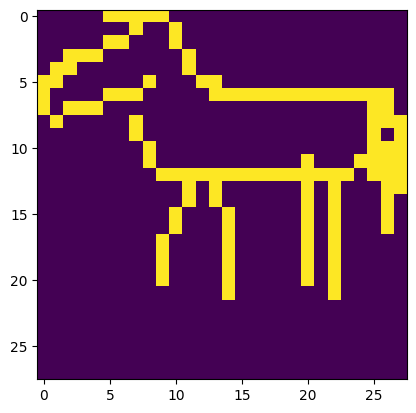

zebra
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 1 1 1 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1]
 [0 0 0 1 1 0 1 1 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1]
 [0 1 1 0 0 0 1 1 0 0 0 0 1 1 0 0 0 0 1 0 0 1 1 1 1 0 0 1]
 [0 1 1 0 0 1 1 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 1 1]
 [1 0 1 1 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [1 1 0 1 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [1 1 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [1 1 1 0 1 1 0 1 1 0 0 1 1 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [1 1 0 1 1 0 0 1 1 1 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0]
 [1 1 1 0 1 1 1 0 0 1 0 1 0 0 0 1 1 0 1 1 0 0 0 0 0 0 0 0]
 [1 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

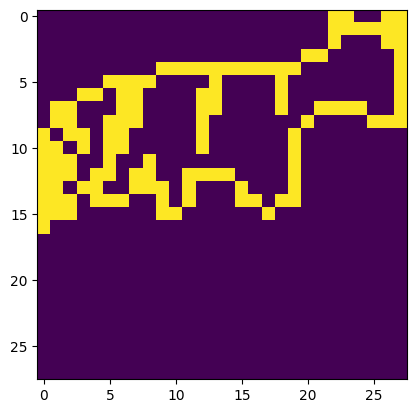

shoe
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1]
 [0 0 0 0 1 1 0 1 0 0 1 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1]
 [0 0 1 1 0 0 0 1 0 0 0 1 0 1 1 1 0 0 0 1 1 0 0 0 0 0 0 1]
 [0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0 1 0]
 [0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 1 0]
 [1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

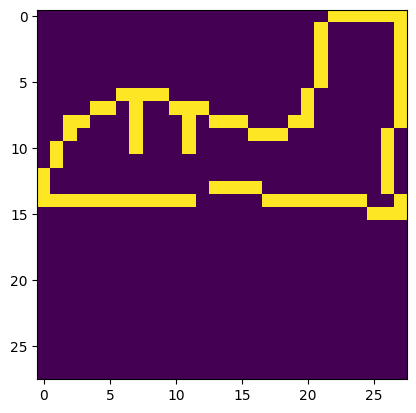

rollerskates
[[0 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

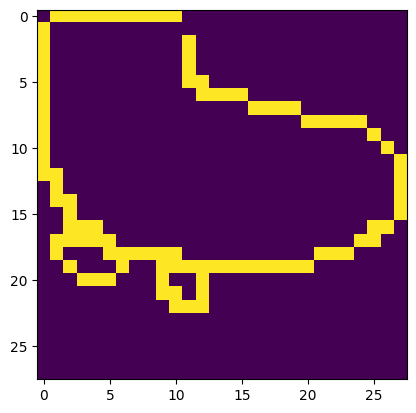

cat
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 1 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 1 1 1 1 1 1 1 1 0 0 0 1 1 1 0 0 0 0 1 1 1 1 1 1 1 1 0]
 [0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 1 1 1 1 0 0 

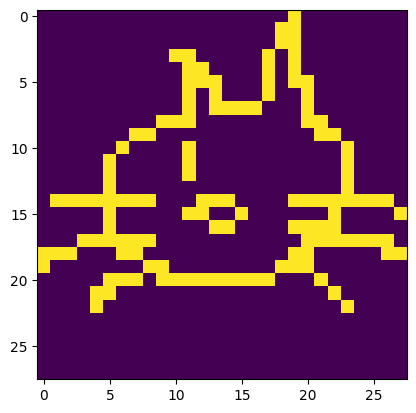

dog
[[0 0 1 1 1 1 1 0 0 0 1 1 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 1 1 1 1 1 1 1 0 0 0 0 0 1 1 1 1 0 0 0 1 0]
 [1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0]
 [1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0]
 [1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 1 1 0 0 0 1 1 0]
 [1 0 0 0 1 1 1 1 0 0 0 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 1 0]
 [1 0 0 0 1 0 0 1 0 0 0 0 1 1 1 0 0 0 0 1 1 0 0 0 0 0 0 1]
 [1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1]
 [1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 1 1 0 0 1 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 1 0 0 1 0 0 0 0 0 

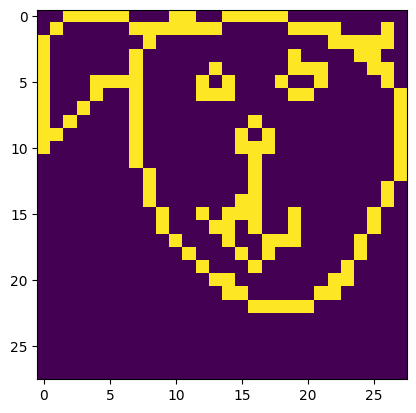

panda
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 0]
 [0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 1]
 [0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 1 0 1]
 [0 1 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 1 0 1 1 1 0 0 0 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 1 0 0 1 1 1 1]
 [1 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 0 1]
 [1 0 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 1 1 0]
 [1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0]
 [1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 1 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0]
 [0 0 1 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 1 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 1 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 

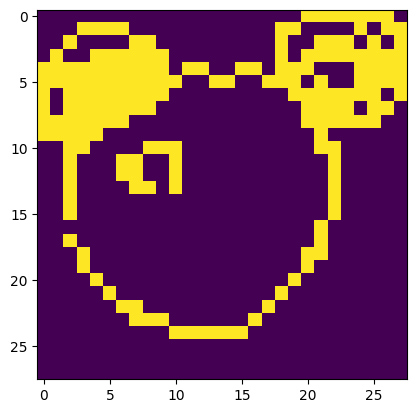

laptop
[[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0]
 [0 0 0 1 1 1 1 1 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 0]
 [1 1 1 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0]
 [1 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0]
 [1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0]
 [1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0]
 [1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0]
 [1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0]
 [1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0]
 [1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0]
 [1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0]
 [1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0]
 [1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 0 0 0 1 0]
 [1 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 0]
 [1 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0

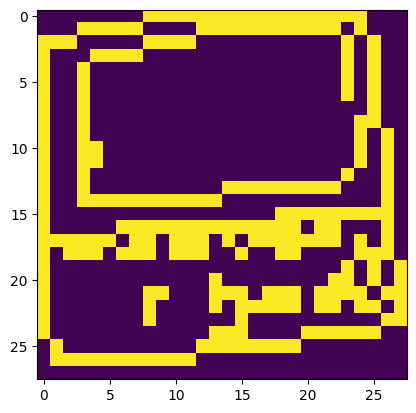

computer
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

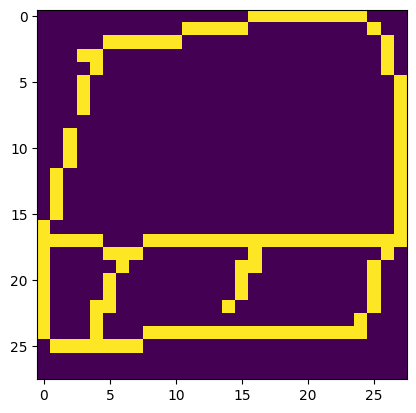

camera
[[0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1]
 [0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 1]
 [0 0 0 0 1 1 0 1 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1]
 [1 1 0 1 1 1 0 1 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 0 0 0 0 1]
 [0 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0 0 0 0 0 1 0 0 0 1 0]
 [0 0 0 1 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 1 0]
 [0 0 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 0 0 0 1 0]
 [0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0]
 [0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0]
 [0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0]
 [1 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 1 0 0 0]
 [1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 1 1 1 1 1 1 1 1 0 1 1 0 0 0 0 0 0 0 0 0 0

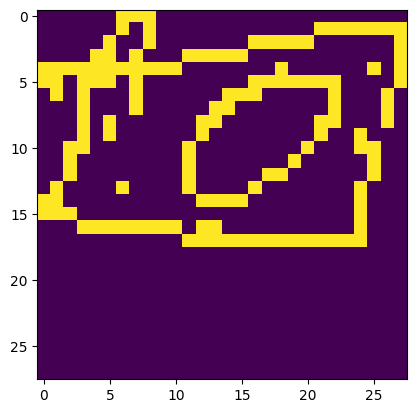

television
[[0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

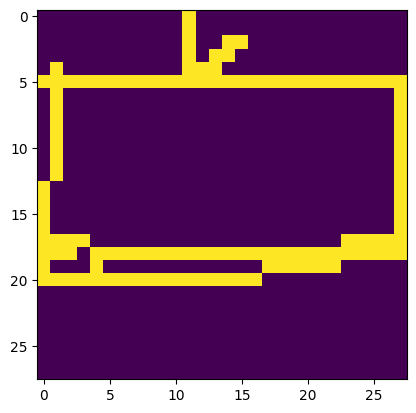

mushroom
[[0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0]
 [0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0

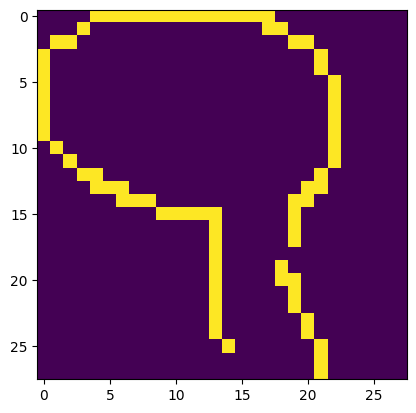

strawberry
[[0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 1 0 0 1 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 1 0 0 1 0 0 1 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 1 0 1 0 0 1 1 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 1 0 1 0 0 1 1 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 1 1 0 1 0 1 0 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 1 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0

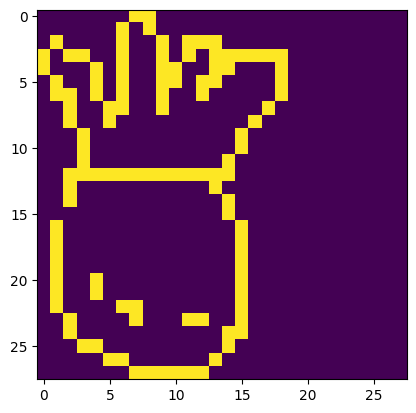

bread
[[0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0]
 [0 1 1 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 1 1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0]
 [0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0]
 [0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 

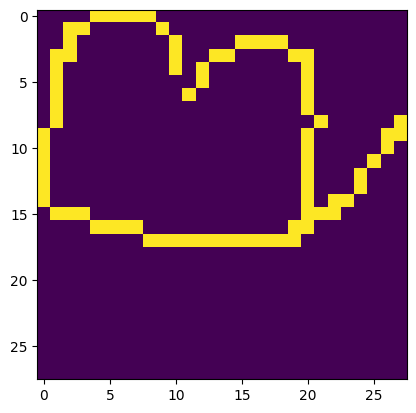

bandage
[[0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0]
 [0 0 0 1 1 1 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0]
 [0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0]
 [1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1]
 [1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

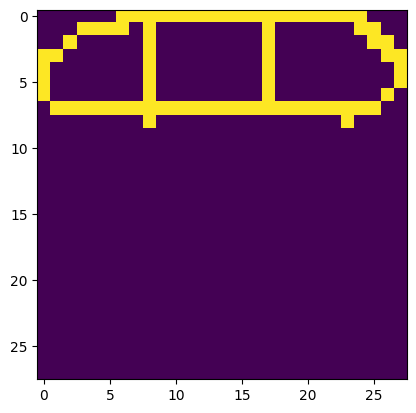

baseball
[[0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 1 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 1 0 0 1 1 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0]
 [0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 1 0 1 1 1 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 1 0 0 0 0]
 [0 1 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 0 0 0]
 [0 1 0 0 0 0 0 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0]
 [1 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1]
 [1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0

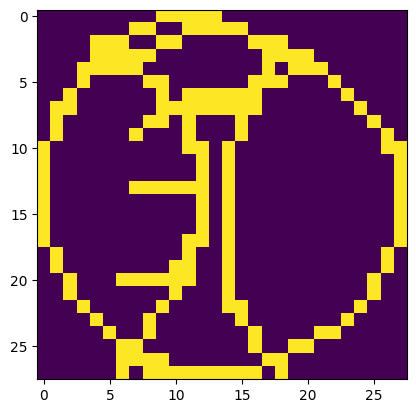

bat
[[0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0]
 [0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 1 0 0 0 1 1 0 1 0 0 0 0 0]
 [0 0 0 0 1 0 0 1 1 0 0 1 0 0 1 0 0 1 1 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 1 0 1 0 0 1 0 1 1 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 1 1 0 0 0 0 0 1 1 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 1 1 1 1]
 [0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 1 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 

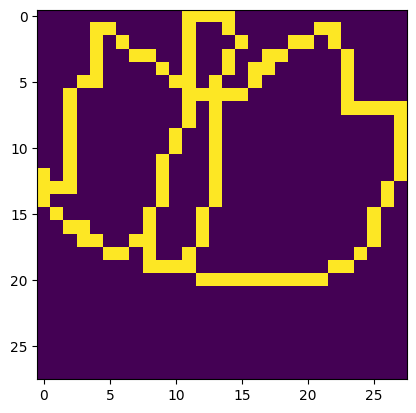

crab
[[0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0]
 [0 0 1 1 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 1 1 0 0 0 0 0]
 [0 1 1 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 1 1 0 0 0]
 [1 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 1 0 0]
 [1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0]
 [1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1]
 [1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0

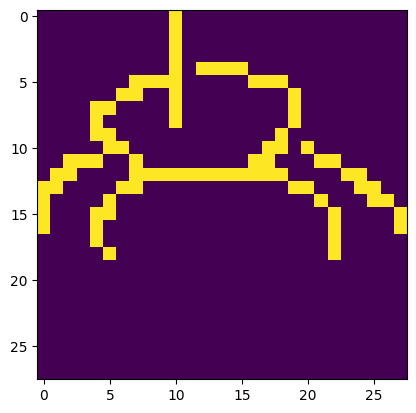

clock
[[0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 1 1 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 1]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 

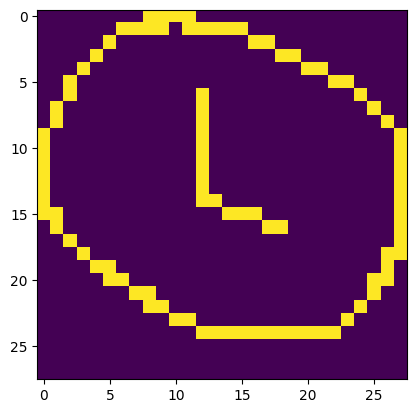

compass
[[0 0 0 0 0 0 1 1 1 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 

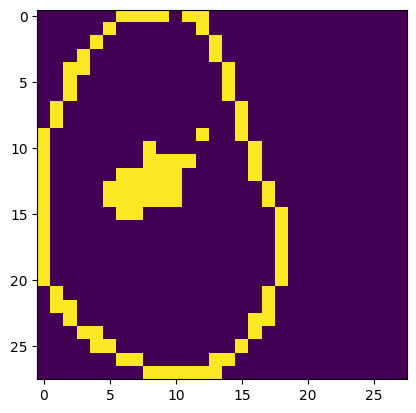

fan
[[0 0 0 0 0 0 1 1 1 1 1 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0]
 [0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0]
 [0 0 1 1 0 0 0 1 1 1 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1]
 [1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 0]
 [1 0 0 0 0 0 0 0 0 1 1 0 1 1 1 1 0 0 0 0 0 0 0 1 1 1 1 0]
 [1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 1]
 [0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

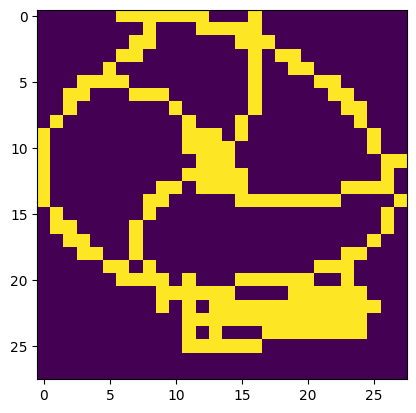

lollipop
[[0 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

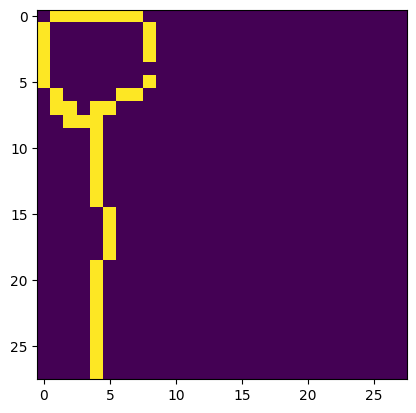

soccer ball
[[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0]
 [0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0]
 [0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1]
 [0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]
 [1 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]
 [1 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 1 1 0 0 0 0 1]
 [1 0 0 0 1 0 0 0 1 1 1 0 1 1 1 0 0 0 0 0 1 0 0 1 0 0 0 1]
 [1 0 0 0 0 1 1 1 1 0 1 1 1 0 1 1 0 0 0 1 0 0 0 0 1 0 0 1]
 [1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1]
 [1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 

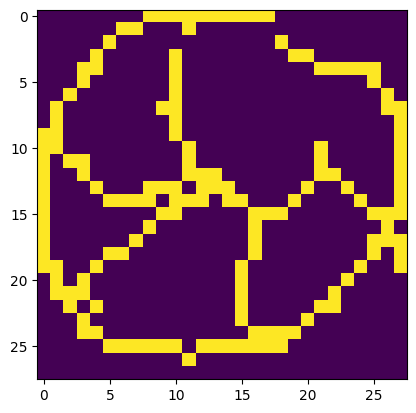

basketball
[[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 1 0 0 0 1 1 0 1 1 1 1 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0]
 [0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0]
 [0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0]
 [0 1 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0]
 [0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 1 0]
 [1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 1]
 [1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1]
 [1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1

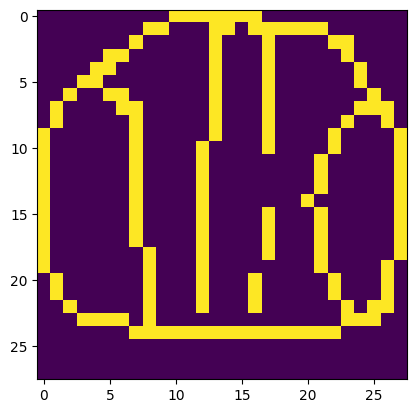

stop sign
[[0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0]
 [0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [1 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1]
 [1 0 0 0 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 1 1 0 0 0 1 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 1]
 [1 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 1]
 [0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 1]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 1]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0]
 [0 0 0 0 1 1 1 1 1 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 

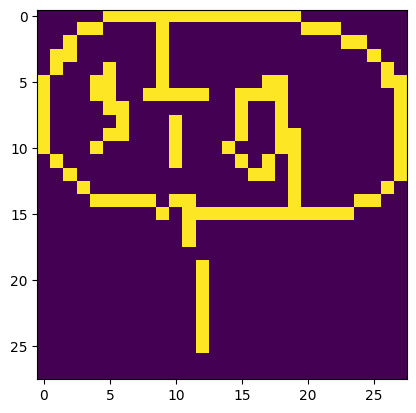

octagon
[[0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

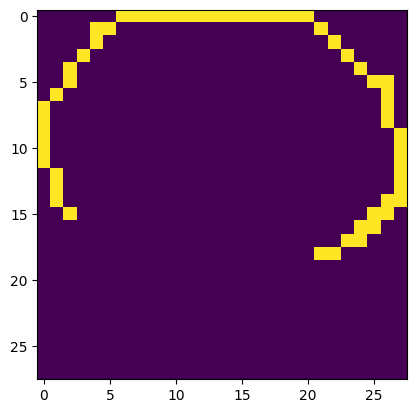

In [ ]:
import PIL.Image as Image
import matplotlib.pyplot as plt

for i in range(len(X)):
  print(y[i])
  print(X[i])

  im = Image.fromarray(X[i])
  plt.imshow(im)
  plt.show()

### 3. Process all the Data from each Class

In [ ]:
classes = [
  "horse", "zebra", "shoe", "rollerskates", "cat", "dog", "panda",
  "laptop", "computer", "camera", "television",
  "mushroom", "strawberry", "bread", "bandage",
  "baseball", "bat", "crab", "clock", "compass", "fan",
  "lollipop", "soccer ball", "basketball",
  "stop sign", "octagon"
]

#binary images
X = []
#labels
y = []

for c in classes:
  filepath = f"quickdraw/{c}.ndjson"
  print("Processing data in:", filepath)
  with open(filepath) as f:
    #process each data point / drawing in the class
    for line in f:
      data = json.loads(line)
      drawing = data["drawing"]
      binary_drawing = vector_drawing_to_binary(drawing)

      #save binary drawing to list
      X.append(binary_drawing)
      #save label to list
      y.append(c)

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)
print("Labels shape:", y.shape)

Processing data in: quickdraw/horse.ndjson
Processing data in: quickdraw/zebra.ndjson
Processing data in: quickdraw/shoe.ndjson
Processing data in: quickdraw/rollerskates.ndjson
Processing data in: quickdraw/cat.ndjson
Processing data in: quickdraw/dog.ndjson
Processing data in: quickdraw/panda.ndjson
Processing data in: quickdraw/laptop.ndjson
Processing data in: quickdraw/computer.ndjson
Processing data in: quickdraw/camera.ndjson
Processing data in: quickdraw/television.ndjson
Processing data in: quickdraw/mushroom.ndjson
Processing data in: quickdraw/strawberry.ndjson
Processing data in: quickdraw/bread.ndjson
Processing data in: quickdraw/bandage.ndjson
Processing data in: quickdraw/baseball.ndjson
Processing data in: quickdraw/bat.ndjson
Processing data in: quickdraw/crab.ndjson
Processing data in: quickdraw/clock.ndjson
Processing data in: quickdraw/compass.ndjson
Processing data in: quickdraw/fan.ndjson
Processing data in: quickdraw/lollipop.ndjson
Processing data in: quickdraw

#### 3a. Number of Data points in each Class:

In [ ]:
from collections import Counter
Counter(y)

Counter({np.str_('horse'): 178286,
         np.str_('zebra'): 144608,
         np.str_('shoe'): 120231,
         np.str_('rollerskates'): 119772,
         np.str_('cat'): 123202,
         np.str_('dog'): 152159,
         np.str_('panda'): 113613,
         np.str_('laptop'): 261501,
         np.str_('computer'): 123885,
         np.str_('camera'): 128772,
         np.str_('television'): 123137,
         np.str_('mushroom'): 142167,
         np.str_('strawberry'): 122301,
         np.str_('bread'): 120570,
         np.str_('bandage'): 147614,
         np.str_('baseball'): 135375,
         np.str_('bat'): 118114,
         np.str_('crab'): 126930,
         np.str_('clock'): 120536,
         np.str_('compass'): 127609,
         np.str_('fan'): 136158,
         np.str_('lollipop'): 128849,
         np.str_('soccer ball'): 125349,
         np.str_('basketball'): 133793,
         np.str_('stop sign'): 119814,
         np.str_('octagon'): 159474})

### 4. Perform Random Undersampling to acquire a balanced subset of the data

In [ ]:
from collections import defaultdict

#Random undersampling with n number of samples per class
def random_undersample(X, y, n, random_state=35):
  np.random.seed(random_state)
  class_indices = defaultdict(list)

  for idx, label in enumerate(y):
    class_indices[label].append(idx)
    selected_indices = []

  for label, indices in class_indices.items():
    sampled = np.random.choice(indices, n, replace=False)
    selected_indices.extend(sampled)

  np.random.shuffle(selected_indices)
  X_new = X[selected_indices]
  y_new = y[selected_indices]
  return X_new, y_new

#### 4a. Apply the undersampling and download the new data

In [ ]:
#Start with 100 samples per class
X_new, y_new = random_undersample(X, y, 1000)

print(X_new.shape)
Counter(y_new)

#Save sampled sets to load for the models instead of re-running previous code
np.save("X_sampled_1000.npy", X_new)
np.save("y_sampled_1000.npy", y_new)

(260000, 28, 28)


#### 4b. Load the data to use for training and testing

**NOTE:** If you have previously saved and downloaded the data in the forms of "x_sampled_n.npy" and "y_sampled_n.npy," you may run the code from this point on and avoid having to re-preprocess the data. Upload the two .npy files to the Colab Files and run the code from this point on.

In [ ]:
import numpy as np
from collections import Counter

#load the saved sample data
X_new = np.load("X_sampled_1000.npy")
y_new = np.load("y_sampled_1000.npy")

print("X shape:", X_new.shape)
print("y shape:", y_new.shape)

Counter(y_new)

X shape: (260000, 28, 28)
y shape: (260000,)


Counter({np.str_('clock'): 10000,
         np.str_('mushroom'): 10000,
         np.str_('strawberry'): 10000,
         np.str_('rollerskates'): 10000,
         np.str_('panda'): 10000,
         np.str_('television'): 10000,
         np.str_('cat'): 10000,
         np.str_('basketball'): 10000,
         np.str_('lollipop'): 10000,
         np.str_('horse'): 10000,
         np.str_('stop sign'): 10000,
         np.str_('zebra'): 10000,
         np.str_('camera'): 10000,
         np.str_('compass'): 10000,
         np.str_('dog'): 10000,
         np.str_('computer'): 10000,
         np.str_('fan'): 10000,
         np.str_('crab'): 10000,
         np.str_('bread'): 10000,
         np.str_('bat'): 10000,
         np.str_('octagon'): 10000,
         np.str_('laptop'): 10000,
         np.str_('shoe'): 10000,
         np.str_('soccer ball'): 10000,
         np.str_('bandage'): 10000,
         np.str_('baseball'): 10000})


---

##Modeling


#1. Train And Test Data Split

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X_flattened = X_new.reshape(X_new.shape[0], -1)

le = LabelEncoder()
y_encoded = le.fit_transform(y_new)

#Split the training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_flattened, y_encoded,
    test_size=0.2,
    stratify=y_new,
    random_state=35
)

# 2. CNN using PyTorch



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

CNN_X_train, CNN_X_test, CNN_y_train, CNN_y_test = train_test_split(
    X_new, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=35
)

In [ ]:
class QuickDrawDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = QuickDrawDataset(CNN_X_train, CNN_y_train)
test_dataset  = QuickDrawDataset(CNN_X_test,  CNN_y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

In [ ]:
class QuickDrawCNN(nn.Module):
    def __init__(self):
        super(QuickDrawCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        # After pool: 12x12x6

        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
        # After pool: 4x4x16

        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 26)

        self.relu    = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 256)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model     = QuickDrawCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Using device: cpu


In [ ]:
CNN_NUM_EPOCHS = 10

for epoch in range(CNN_NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total   = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted  = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total   += labels.size(0)

    train_acc = 100 * correct / total
    avg_loss  = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{CNN_NUM_EPOCHS}] | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}%")

Epoch [1/10] | Loss: 0.6586 | Train Acc: 79.60%
Epoch [2/10] | Loss: 0.6501 | Train Acc: 79.91%
Epoch [3/10] | Loss: 0.6445 | Train Acc: 80.07%
Epoch [4/10] | Loss: 0.6370 | Train Acc: 80.33%
Epoch [5/10] | Loss: 0.6313 | Train Acc: 80.47%
Epoch [6/10] | Loss: 0.6256 | Train Acc: 80.55%
Epoch [7/10] | Loss: 0.6206 | Train Acc: 80.75%
Epoch [8/10] | Loss: 0.6153 | Train Acc: 80.87%
Epoch [9/10] | Loss: 0.6111 | Train Acc: 80.98%
Epoch [10/10] | Loss: 0.6078 | Train Acc: 81.14%


In [ ]:
model.eval()
correct = 0
total   = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs        = model(images)
        _, predicted   = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total   += labels.size(0)

print(f"\nTest Accuracy: {100 * correct / total:.2f}%")


Test Accuracy: 78.86%


With 100 samples from each class, the CNN model has an accuracy of 0.378.

With 1000 samples from each class, the CNN model has an accuracy of 0.643.

With 10000 samples from each class, the CNN model has an accuracy of 0.779.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

cm = confusion_matrix(all_labels, all_preds)

cm_errors = cm.copy()

class_names = le.classes_

plt.figure(figsize=(16, 13))
sns.heatmap(
    cm_errors,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)
plt.title("Pairwise Error Heatmap", fontsize=14)
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("True Class", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 3. SVM using Skikit Learn

SVC Documentation: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier
from sklearn.decomposition import IncrementalPCA

import time

start = time.time()

#SVM_model = SVC(kernel='rbf', C=1, gamma='scale')
#SVM_model.fit(X_train, y_train)

#Use Pipeline instead to normalize data and reduce dimensionality (PCA)
SVM_model = Pipeline([
    ('scaler', StandardScaler()),
    ("pca", PCA(n_components=100, svd_solver='randomized')),
    ("svm",SVC(C=1,kernel='rbf')),
])

SVM_model.fit(X_train, y_train)

end = time.time()
print(f"Training time: {end - start:.2f} seconds")

In [ ]:
import joblib

#Save the model when it is done training
joblib.dump(SVM_model, "svm_model_1000.pkl")

In [ ]:
import joblib

#Load the model to use for evaluation
SVM_model = joblib.load("svm_model_1000.pkl")

In [ ]:
from sklearn.metrics import accuracy_score

#Test accuracy to see how performs
y_pred = SVM_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

# 4. Vision Transformer (ViT)


Data preprocessing for the ViT


In [ ]:
import os
import json
import numpy as np

# ---------------------------------
# Read QuickDraw ndjson files
# ---------------------------------
X_list = []
y_list = []

max_read_per_class = 20000   # read enough so we can keep 10k non-blank later

for cls in classes:
    path = f"quickdraw/{cls}.ndjson"
    count = 0

    with open(path, "r") as f:
        for line in f:
            obj = json.loads(line)

            # skip bad records
            if "drawing" not in obj:
                continue

            # QuickDraw simplified often has recognized flag
            if "recognized" in obj and not obj["recognized"]:
                continue

            # convert strokes -> 28x28 image
            canvas = np.zeros((28, 28), dtype=np.uint8)

            for stroke in obj["drawing"]:
                xs = stroke[0]
                ys = stroke[1]

                for x, y in zip(xs, ys):
                    xi = min(27, max(0, int(x * 28 / 256)))
                    yi = min(27, max(0, int(y * 28 / 256)))
                    canvas[yi, xi] = 255

            X_list.append(canvas)
            y_list.append(cls)

            count += 1
            if count >= max_read_per_class:
                break

    print(f"{cls}: loaded {count}")

# ---------------------------------
# Final raw dataset
# ---------------------------------
X = np.stack(X_list)
y = np.array(y_list)

print("X shape:", X.shape)
print("y shape:", y.shape)

In [ ]:
import numpy as np

# -------------------------
# 1. load raw data
# -------------------------
if 'X' in globals():
    data_X = X
elif 'X_new' in globals():
    data_X = X_new
else:
    raise ValueError("No image data found")

if 'y' in globals():
    data_y = y
elif 'y_new' in globals():
    data_y = y_new
else:
    raise ValueError("No label data found")

data_y = np.array(data_y)
data_X = data_X if data_X.ndim == 3 else data_X.reshape(-1, 28, 28)

print("Original dataset:", data_X.shape, len(data_y))

# -------------------------
# 2. remove blank / near-blank images
# -------------------------
# adjust threshold if needed
non_blank_mask = data_X.reshape(len(data_X), -1).sum(axis=1) > 10

data_X = data_X[non_blank_mask]
data_y = data_y[non_blank_mask]

print("After removing blank images:", data_X.shape, len(data_y))

# -------------------------
# 3. keep up to 10,000 non-blank images per class
# -------------------------
max_per_class = 10000
rng = np.random.default_rng(35)

selected_idx = []
classes = np.unique(data_y)

for cls in classes:
    cls_idx = np.where(data_y == cls)[0]
    take = min(max_per_class, len(cls_idx))
    chosen = rng.choice(cls_idx, size=take, replace=False)
    selected_idx.extend(chosen)
    print(f"{cls}: kept {take} images")

selected_idx = np.array(selected_idx)
rng.shuffle(selected_idx)

data_X = data_X[selected_idx]
data_y = data_y[selected_idx]

print("Final subset:", data_X.shape, len(data_y))

# -------------------------
# 4. now preprocess only this subset
# -------------------------
# convert dtype only after subsetting
if data_X.dtype != np.uint8:
    if data_X.max() <= 1:
        data_X = (data_X * 255).astype(np.uint8)
    else:
        data_X = data_X.astype(np.uint8)

# optional: save as processed variables for later cells
X_new = data_X
y_new = data_y

print("Processed subset ready:")
print("X_new shape:", X_new.shape)
print("y_new length:", len(y_new))

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from torchvision.models import vit_b_16, ViT_B_16_Weights
from PIL import Image

# -------------------------
# 1. load existing data
# -------------------------
if 'X_new' in globals():
    data_X = X_new
elif 'X' in globals():
    data_X = X
else:
    raise ValueError("No image data found")

if 'y_new' in globals():
    data_y = y_new
elif 'y' in globals():
    data_y = y
else:
    raise ValueError("No label data found")

data_y = np.array(data_y)
data_X = data_X if data_X.ndim == 3 else data_X.reshape(-1, 28, 28)

if data_X.dtype != np.uint8:
    if data_X.max() <= 1:
        data_X = (data_X * 255).astype(np.uint8)
    else:
        data_X = data_X.astype(np.uint8)

# -------------------------
# 2. sample 100 images per class
# -------------------------
samples_per_class = 100
rng = np.random.default_rng(35)

selected_idx = []
classes = np.unique(data_y)

for cls in classes:
    cls_idx = np.where(data_y == cls)[0]
    take = min(samples_per_class, len(cls_idx))
    chosen = rng.choice(cls_idx, size=take, replace=False)
    selected_idx.extend(chosen)

selected_idx = np.array(selected_idx)
rng.shuffle(selected_idx)

data_X = data_X[selected_idx]
data_y = data_y[selected_idx]

print("Total selected images:", len(data_X))
print("Number of classes:", len(np.unique(data_y)))

# -------------------------
# 3. encode labels
# -------------------------
le = LabelEncoder()
vit_y = le.fit_transform(data_y)

# -------------------------
# 4. split train/test
# -------------------------
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    data_X,
    vit_y,
    test_size=0.2,
    stratify=vit_y,
    random_state=35
)

print("Train size:", len(X_train_raw))
print("Test size:", len(X_test_raw))

# -------------------------
# 5. precompute transformed images
# -------------------------
weights = ViT_B_16_Weights.DEFAULT
transform = weights.transforms()

def precompute_images(X_raw, transform):
    out = []
    for i, img in enumerate(X_raw):
        if i % 200 == 0:
            print(f"Processed {i}/{len(X_raw)}")
        pil_img = Image.fromarray(img).convert("RGB")
        out.append(transform(pil_img))
    return torch.stack(out)

print("Precomputing train images...")
X_train_tensor = precompute_images(X_train_raw, transform)

print("Precomputing test images...")
X_test_tensor = precompute_images(X_test_raw, transform)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# -------------------------
# 6. build model
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = vit_b_16(weights=weights)

for param in model.parameters():
    param.requires_grad = False

model.heads.head = nn.Linear(model.heads.head.in_features, len(le.classes_))
model = model.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.heads.head.parameters(), lr=1e-3)

# -------------------------
# 7. train and print accuracy each epoch
# -------------------------
epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    train_preds, train_true = [], []

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = loss_fn(outputs, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_true.extend(yb.cpu().numpy())

    train_acc = accuracy_score(train_true, train_preds)

    model.eval()
    test_preds, test_true = [], []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            outputs = model(xb)
            preds = outputs.argmax(dim=1)

            test_preds.extend(preds.cpu().numpy())
            test_true.extend(yb.cpu().numpy())

    test_acc = accuracy_score(test_true, test_preds)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Loss: {total_loss / len(train_loader):.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

# -------------------------
# 8. final report
# -------------------------
print("\nFinal classification report:")
print(classification_report(test_true, test_preds, target_names=le.classes_))

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from torchvision.models import vit_b_16, ViT_B_16_Weights
from PIL import Image

# -------------------------
# 1. load existing data
# -------------------------
if 'X_new' in globals():
    data_X = X_new
elif 'X' in globals():
    data_X = X
else:
    raise ValueError("No image data found")

if 'y_new' in globals():
    data_y = y_new
elif 'y' in globals():
    data_y = y
else:
    raise ValueError("No label data found")

data_y = np.array(data_y)
data_X = data_X if data_X.ndim == 3 else data_X.reshape(-1, 28, 28)

if data_X.dtype != np.uint8:
    if data_X.max() <= 1:
        data_X = (data_X * 255).astype(np.uint8)
    else:
        data_X = data_X.astype(np.uint8)

# -------------------------
# 2. sample 100 images per class
# -------------------------
samples_per_class = 1000
rng = np.random.default_rng(35)

selected_idx = []
classes = np.unique(data_y)

for cls in classes:
    cls_idx = np.where(data_y == cls)[0]
    take = min(samples_per_class, len(cls_idx))
    chosen = rng.choice(cls_idx, size=take, replace=False)
    selected_idx.extend(chosen)

selected_idx = np.array(selected_idx)
rng.shuffle(selected_idx)

data_X = data_X[selected_idx]
data_y = data_y[selected_idx]

print("Total selected images:", len(data_X))
print("Number of classes:", len(np.unique(data_y)))

# -------------------------
# 3. encode labels
# -------------------------
le = LabelEncoder()
vit_y = le.fit_transform(data_y)

# -------------------------
# 4. split train/test
# -------------------------
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    data_X,
    vit_y,
    test_size=0.2,
    stratify=vit_y,
    random_state=35
)

print("Train size:", len(X_train_raw))
print("Test size:", len(X_test_raw))

# -------------------------
# 5. precompute transformed images
# -------------------------
weights = ViT_B_16_Weights.DEFAULT
transform = weights.transforms()

def precompute_images(X_raw, transform):
    out = []
    for i, img in enumerate(X_raw):
        if i % 2000 == 0:
            print(f"Processed {i}/{len(X_raw)}")
        pil_img = Image.fromarray(img).convert("RGB")
        out.append(transform(pil_img))
    return torch.stack(out)

print("Precomputing train images...")
X_train_tensor = precompute_images(X_train_raw, transform)

print("Precomputing test images...")
X_test_tensor = precompute_images(X_test_raw, transform)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# -------------------------
# 6. build model
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = vit_b_16(weights=weights)

for param in model.parameters():
    param.requires_grad = False

model.heads.head = nn.Linear(model.heads.head.in_features, len(le.classes_))
model = model.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.heads.head.parameters(), lr=1e-3)

# -------------------------
# 7. train and print accuracy each epoch
# -------------------------
epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    train_preds, train_true = [], []

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = loss_fn(outputs, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_true.extend(yb.cpu().numpy())

    train_acc = accuracy_score(train_true, train_preds)

    model.eval()
    test_preds, test_true = [], []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            outputs = model(xb)
            preds = outputs.argmax(dim=1)

            test_preds.extend(preds.cpu().numpy())
            test_true.extend(yb.cpu().numpy())

    test_acc = accuracy_score(test_true, test_preds)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Loss: {total_loss / len(train_loader):.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

# -------------------------
# 8. final report
# -------------------------
print("\nFinal classification report:")
print(classification_report(test_true, test_preds, target_names=le.classes_))

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from torchvision.models import vit_b_16, ViT_B_16_Weights
from PIL import Image

# -------------------------
# 1. load existing data
# -------------------------
if 'X_new' in globals():
    data_X = X_new
elif 'X' in globals():
    data_X = X
else:
    raise ValueError("No image data found")

if 'y_new' in globals():
    data_y = y_new
elif 'y' in globals():
    data_y = y
else:
    raise ValueError("No label data found")

data_y = np.array(data_y)
data_X = data_X if data_X.ndim == 3 else data_X.reshape(-1, 28, 28)

if data_X.dtype != np.uint8:
    if data_X.max() <= 1:
        data_X = (data_X * 255).astype(np.uint8)
    else:
        data_X = data_X.astype(np.uint8)

# -------------------------
# 2. sample 100 images per class
# -------------------------
samples_per_class = 5000
rng = np.random.default_rng(35)

selected_idx = []
classes = np.unique(data_y)

for cls in classes:
    cls_idx = np.where(data_y == cls)[0]
    take = min(samples_per_class, len(cls_idx))
    chosen = rng.choice(cls_idx, size=take, replace=False)
    selected_idx.extend(chosen)

selected_idx = np.array(selected_idx)
rng.shuffle(selected_idx)

data_X = data_X[selected_idx]
data_y = data_y[selected_idx]

print("Total selected images:", len(data_X))
print("Number of classes:", len(np.unique(data_y)))

# -------------------------
# 3. encode labels
# -------------------------
le = LabelEncoder()
vit_y = le.fit_transform(data_y)

# -------------------------
# 4. split train/test
# -------------------------
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    data_X,
    vit_y,
    test_size=0.2,
    stratify=vit_y,
    random_state=35
)

print("Train size:", len(X_train_raw))
print("Test size:", len(X_test_raw))

# -------------------------
# 5. precompute transformed images
# -------------------------
weights = ViT_B_16_Weights.DEFAULT
transform = weights.transforms()

def precompute_images(X_raw, transform):
    out = []
    for i, img in enumerate(X_raw):
        if i % 10000 == 0:
            print(f"Processed {i}/{len(X_raw)}")
        pil_img = Image.fromarray(img).convert("RGB")
        out.append(transform(pil_img))
    return torch.stack(out)

print("Precomputing train images...")
X_train_tensor = precompute_images(X_train_raw, transform)

print("Precomputing test images...")
X_test_tensor = precompute_images(X_test_raw, transform)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# -------------------------
# 6. build model
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = vit_b_16(weights=weights)

for param in model.parameters():
    param.requires_grad = False

model.heads.head = nn.Linear(model.heads.head.in_features, len(le.classes_))
model = model.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.heads.head.parameters(), lr=1e-3)

# -------------------------
# 7. train and print accuracy each epoch
# -------------------------
epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    train_preds, train_true = [], []

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = loss_fn(outputs, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_true.extend(yb.cpu().numpy())

    train_acc = accuracy_score(train_true, train_preds)

    model.eval()
    test_preds, test_true = [], []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            outputs = model(xb)
            preds = outputs.argmax(dim=1)

            test_preds.extend(preds.cpu().numpy())
            test_true.extend(yb.cpu().numpy())

    test_acc = accuracy_score(test_true, test_preds)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Loss: {total_loss / len(train_loader):.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

# -------------------------
# 8. final report
# -------------------------
print("\nFinal classification report:")
print(classification_report(test_true, test_preds, target_names=le.classes_))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

cm = confusion_matrix(all_labels, all_preds)

cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)

class_names = le.classes_

plt.figure(figsize=(16, 13))
sns.heatmap(
    cm_errors,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)
plt.title("Pairwise Error Heatmap", fontsize=14)
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("True Class", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


---

##Evaluation

### SVM Model

**For 1000 samples per class:**

Training time: 47.13 seconds

Train Accuracy: 0.837

Test Accuracy:  0.644

CV Accuracy: [0.61706731 0.65024038 0.63798077 0.63317308 0.63942308]

Mean: 0.635576923076923

Std: 0.010807153353657352

**For 5000 samples per class:**

Training time: 1341.05 seconds

Train Accuracy: 0.836

Test Accuracy:  0.719

Prediction time: 2214.02 seconds

**For 10,000 samples per class:**

Training time: 5521.07 seconds

Train Accuracy: 0.835

Test Accuracy: 0.778

Prediction time: 11042 seconds

In [ ]:
import joblib

#Load the model to use for evaluation
SVM_model = joblib.load("svm_model_1000.pkl")

In [ ]:
from sklearn.metrics import accuracy_score
import time

start = time.time()

y_train_pred = SVM_model.predict(X_train)
y_test_pred = SVM_model.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy:  {test_acc:.3f}")

end = time.time()
print(f"Prediction time: {end - start:.2f} seconds")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predictions
all_preds = y_test_pred
all_labels = y_test

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)

class_names = le.classes_

plt.figure(figsize=(16, 13))
sns.heatmap(
    cm_errors,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)
plt.title("Pairwise Error Heatmap", fontsize=14)
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("True Class", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    SVM_model,
    X_train,
    y_train,
    cv=3,
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_sizes, train_mean, label="Train")
plt.plot(train_sizes, test_mean, label="Validation")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Learning Curve")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_pred, target_names=le.classes_))

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(SVM_model, X_train, y_train, cv=5, n_jobs=-1)

print("CV Accuracy:", scores)
print("Mean:", scores.mean())
print("Std:", scores.std())


---

##Result Analysis

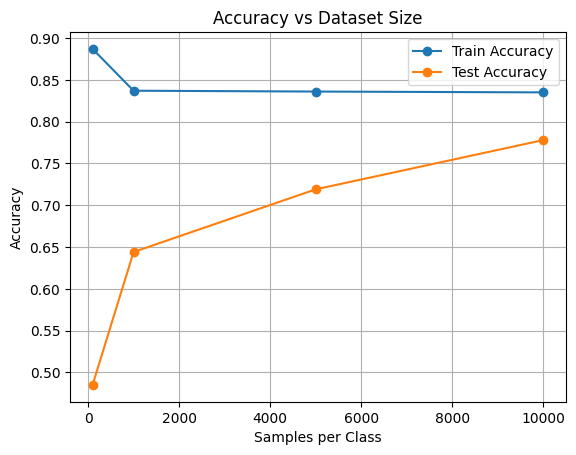

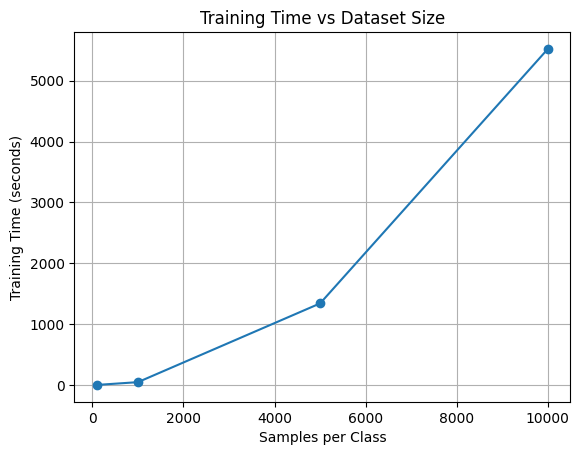

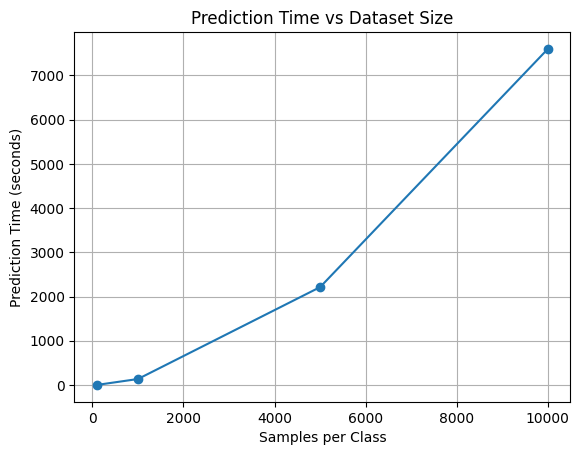

In [ ]:
import matplotlib.pyplot as plt

# Data
samples = [100, 1000, 5000, 10000]

train_acc = [0.887, 0.837, 0.836, 0.835]
test_acc = [0.485, 0.644, 0.719, 0.778]

train_time = [1.65, 47.13, 1341.05, 5521]
pred_time = [1.79, 135.41, 2214.02, 7601]

plt.figure()
plt.plot(samples, train_acc, marker='o', label='Train Accuracy')
plt.plot(samples, test_acc, marker='o', label='Test Accuracy')

plt.xlabel("Samples per Class")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Dataset Size")
plt.legend()
plt.grid()

plt.show()

plt.figure()
plt.plot(samples, train_time, marker='o')

plt.xlabel("Samples per Class")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time vs Dataset Size")
plt.grid()

plt.show()

plt.figure()
plt.plot(samples, pred_time, marker='o')

plt.xlabel("Samples per Class")
plt.ylabel("Prediction Time (seconds)")
plt.title("Prediction Time vs Dataset Size")
plt.grid()

plt.show()